## 1. Imports & Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = sns.color_palette('Set2')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load the Dataset

The dataset is stored as an Excel file. We load it into a pandas DataFrame and immediately inspect its **dimensions** and the **first few rows** to get a sense of what we are working with.

In [33]:
df = pd.read_excel('../data/processed/final_dataset.xlsx')

print(f'Initial shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Initial shape: 77 rows × 61 columns


,model,organization,publication_date,domain,task,parameters,training_flops,training_dataset,dataset_size,confidence,...,upload_date,submission_date,generation,base_model_hf,license,hub_likes,parameters_billions,co2_cost,model_key_name,model_key_base
0,QwQ-32B,Alibaba,2025-03-06,Language,"Language modeling/generation,Question answerin...",3.250000e+10,3.510000e+24,Unspecified unreleased,NaN,Speculative,...,2025-03-05,2025-03-11,1,Qwen/Qwen2.5-32B,apache-2.0,2407,32.764,48.305289,qwq32b,qwen2532b
1,QwQ-32B,Alibaba,2025-03-06,Language,"Language modeling/generation,Question answerin...",3.250000e+10,3.510000e+24,Unspecified unreleased,NaN,Speculative,...,2024-11-27,2024-11-29,2,Qwen/Qwen2.5-32B,apache-2.0,1722,32.764,20.420780,qwq32b,qwen2532b
2,Apollo 7B,"Meta AI,Stanford University",2024-12-13,"Video,Language,Multimodal",Video description,7.000000e+09,NaN,Unspecified unreleased,NaN,Confident,...,2025-03-02,2025-03-02,1,rootxhacker/apollo-7B (Merge),mit,0,7.616,1.468812,apollo7b,apollo7b
3,EXAONE 3.5 32B,LG AI Research,2024-12-09,Language,"Language modeling/generation,Question answerin...",3.200000e+10,1.250000e+24,Unspecified unreleased,6.500000e+12,Confident,...,2024-12-01,2025-01-13,0,LGAI-EXAONE/EXAONE-3.5-32B-Instruct,other,113,32.003,30.995242,exaone3532b,exaone3532b
4,Llama 3.3 70B,Meta AI,2024-12-06,Language,"Language modeling/generation,Question answerin...",7.000000e+10,6.864977e+24,Unspecified unreleased,1.500000e+13,Confident,...,2024-11-26,2024-12-03,1,meta-llama/Llama-3.3-70B-Instruct (Merge),llama3.3,2169,70.554,76.559074,llama3370b,llama3370b


### What we found

The dataset loaded into the notebook contains **77 rows and 61 columns**. Each row represents one LLM model entry or evaluation record. Key columns include:

- `model` — model name
- `organization` — organisation that built or released the model
- `parameters` — total number of model parameters
- `training_flops` — estimated compute used during training
- `dataset_size` — size of the training dataset
- `co2_cost` — estimated CO₂ cost associated with training
- `hub_likes` — community popularity score on Hugging Face Hub

The dataset combines numeric variables, such as parameters, FLOPs, benchmark scores and CO₂ cost, with categorical/text variables, such as model name, organisation, domain, task, license and training dataset. Therefore, numeric and categorical columns need to be handled separately during preprocessing.

### Column data types overview

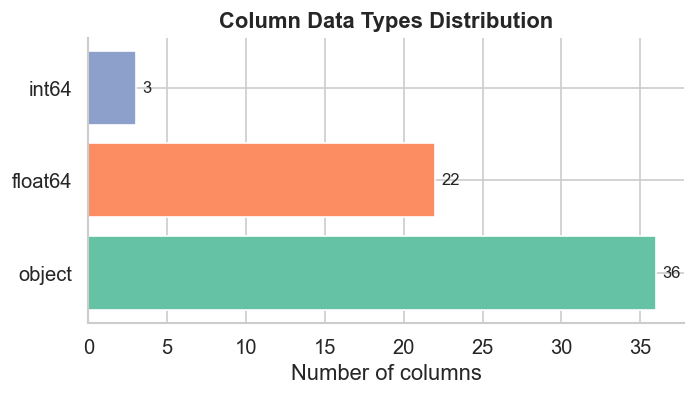

object     36
float64    22
int64       3
Name: count, dtype: int64


In [34]:
dtype_counts = df.dtypes.astype(str).value_counts()

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(dtype_counts.index, dtype_counts.values, color=PALETTE[:len(dtype_counts)])
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of columns')
ax.set_title('Column Data Types Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

print(dtype_counts)

### Interpretation

The chart confirms that the majority of columns are **`object` (text/categorical)**, followed by a meaningful block of **`float64` numeric** columns. A few `datetime64` columns capture publication and evaluation dates.

**Implication for preprocessing:** imputation and transformation will only be applied to `float64` columns. Categorical columns are left as-is for now and would require a separate encoding step before modelling.

---
## 3. Missing Value Analysis

### Missing Value Percentage

The table below reports the percentage of missing values for each column containing incomplete observations. Expressing missingness as a percentage makes it easier to compare variables with different levels of completeness and provides a clearer basis for deciding how each feature should be treated.

Columns with very low percentages of missing values can usually be imputed with minimal impact on the overall distribution. In contrast, variables with a high proportion of missing entries may be less reliable and should be interpreted with greater caution.

In [ ]:
# Percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df) * 100)
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Display summary table
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': missing_percentage
}).dropna()

missing_summary

,Missing Values,Percentage (%)
base_model,64,83.116883
dataset_size,18,23.376623
epochs,44,57.142857
has_chat_template,21,27.272727
is_moe,71,92.207792
numerical_format,25,32.467532
official_provider,39,50.649351
parameters,1,1.298701
submission_date,1,1.298701
training_dataset,2,2.597403


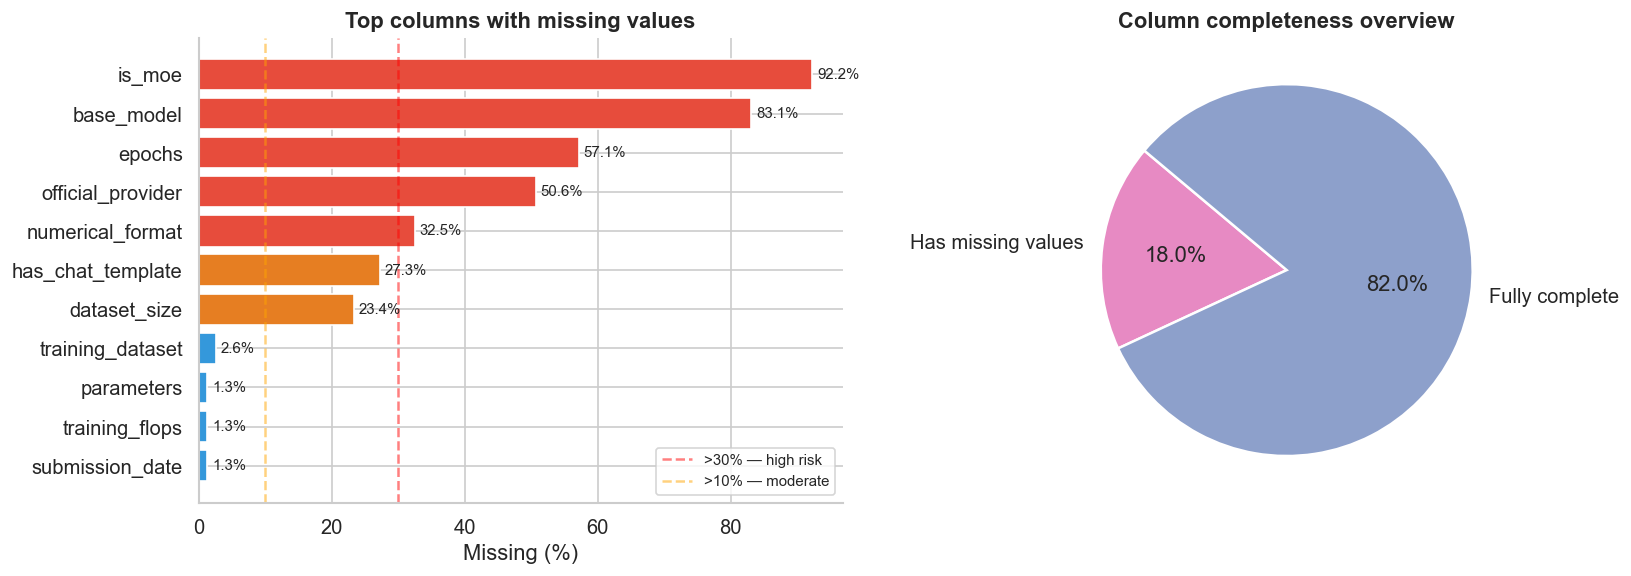

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values summary
missing_nonzero = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': df.isnull().mean() * 100
})

# Keep only columns with at least one missing value
missing_nonzero = missing_nonzero[missing_nonzero['Missing Values'] > 0]

# Sort from highest to lowest missing percentage
missing_nonzero = missing_nonzero.sort_values('Percentage (%)', ascending=False)

# ── Left: horizontal bar chart coloured by severity ────────────────
top = missing_nonzero.head(15)
colors = ['#e74c3c' if p > 30 else '#e67e22' if p > 10 else '#3498db'
          for p in top['Percentage (%)']]
bars = axes[0].barh(top.index[::-1], top['Percentage (%)'][::-1], color=colors[::-1])
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Top columns with missing values', fontweight='bold')
axes[0].axvline(30, color='red', linestyle='--', alpha=0.5, label='>30% — high risk')
axes[0].axvline(10, color='orange', linestyle='--', alpha=0.5, label='>10% — moderate')
axes[0].legend(fontsize=9)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

# ── Right: pie — columns with vs without missing ───────────────────
n_with = len(missing_nonzero)
n_without = len(df.columns) - n_with
axes[1].pie(
    [n_with, n_without],
    labels=['Has missing values', 'Fully complete'],
    colors=[PALETTE[3], PALETTE[2]],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Column completeness overview', fontweight='bold')

plt.tight_layout()
plt.show()

### Missing Data Pattern

The heatmap visualises the distribution of missing values across all rows and columns. Each coloured cell represents a missing observation, while complete values remain uncoloured.

This representation helps determine whether missing values are randomly scattered throughout the dataset or concentrated in specific variables. In this case, missingness is largely concentrated in a limited set of columns rather than being evenly distributed across the entire dataset.

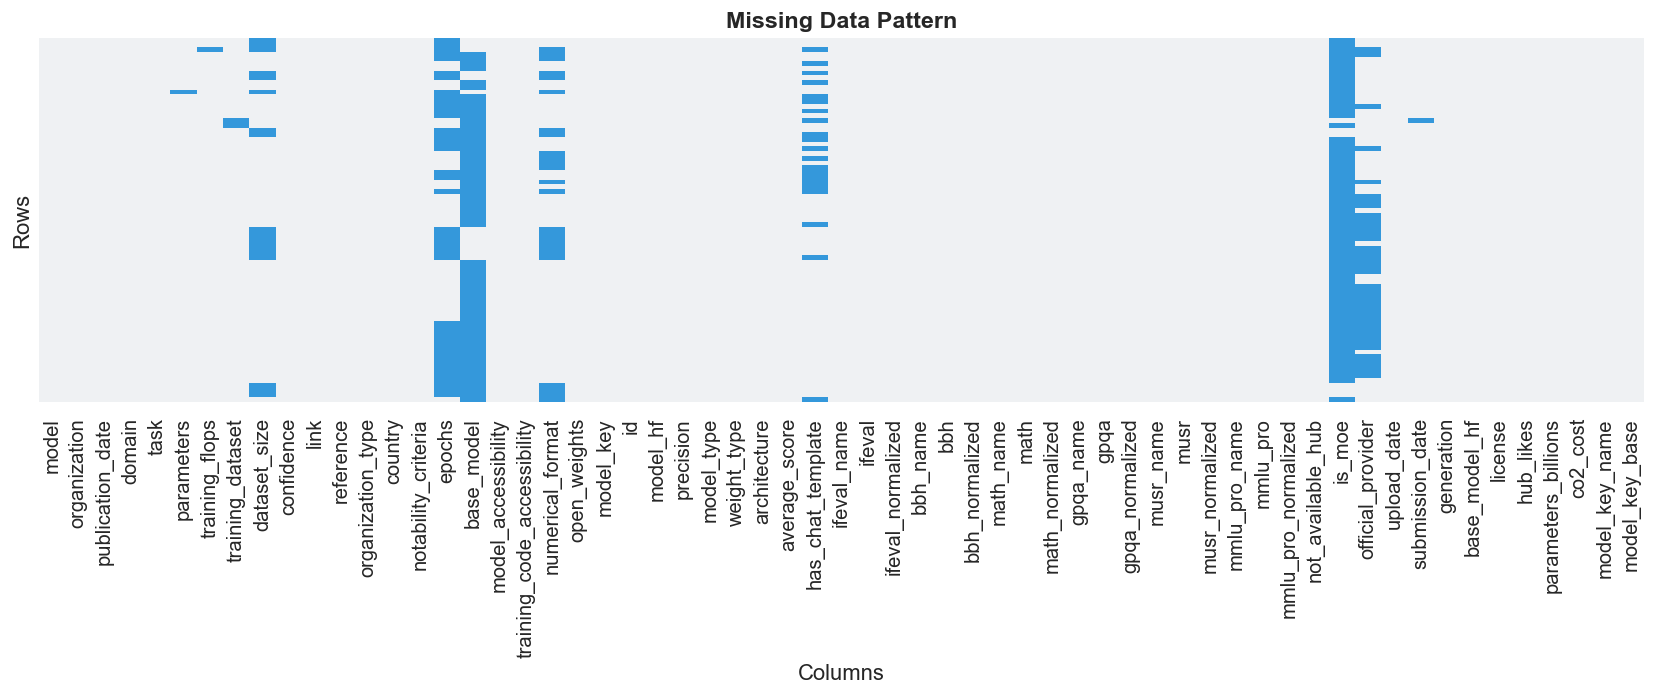

In [ ]:
# Missing Data Heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap=sns.light_palette("#3498db", as_cmap=True)  # Blue palette matching the notebook style
)

plt.title("Missing Data Pattern", fontsize=14, fontweight="bold")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### Missingness Categories

To facilitate interpretation, variables are grouped according to their percentage of missing values:

- **Low (<5%)**: variables with only a few missing values, which can generally be imputed with little impact.
- **Moderate (5–30%)**: variables requiring more careful consideration before imputation.
- **High (>30%)**: highly incomplete variables that may be unreliable and should be treated cautiously.

This classification provides a structured framework for deciding whether a variable should be imputed, retained with caution, or potentially excluded from subsequent modelling.

In [41]:
def classify_missing(p):
    if p < 5:
        return 'Low (<5%)'
    elif p < 30:
        return 'Moderate (5–30%)'
    else:
        return 'High (>30%)'

missing_summary['Category'] = missing_summary['Percentage (%)'].apply(classify_missing)
missing_summary

,Missing Values,Percentage (%),Category
base_model,64,83.116883,High (>30%)
dataset_size,18,23.376623,Moderate (5–30%)
epochs,44,57.142857,High (>30%)
has_chat_template,21,27.272727,Moderate (5–30%)
is_moe,71,92.207792,High (>30%)
numerical_format,25,32.467532,High (>30%)
official_provider,39,50.649351,High (>30%)
parameters,1,1.298701,Low (<5%)
submission_date,1,1.298701,Low (<5%)
training_dataset,2,2.597403,Low (<5%)


### Interpretation

The missing value analysis reveals a **highly uneven completeness profile** across the 61 columns:

- **`is_moe`** is the most incomplete variable, with more than **90% missing values**. This is expected, as many model cards do not explicitly report whether a model uses a Mixture-of-Experts architecture.
- **`base_model`** also contains a very high proportion of missing values, indicating that the original parent model is often not documented.
- **`epochs`** has approximately **57% missing values**, reflecting the fact that many LLM developers do not disclose the number of training epochs.
- **`official_provider`** and **`numerical_format`** are also highly incomplete, both exceeding the 30% threshold.
- **`dataset_size`** presents moderate missingness, while core technical variables such as `parameters` and `training_flops` contain only a few missing observations.
- A substantial portion of the dataset is fully complete, indicating that missingness is concentrated in a relatively small subset of technical and metadata variables.

> **Key takeaway:** variables with more than 30% missing values should be interpreted with caution, even after imputation. Replacing a large fraction of observations with synthetic values reduces variance and may introduce artificial patterns. In a more advanced pipeline, these variables could be excluded or imputed using more sophisticated methods such as KNN or model-based approaches.

---
## 4. Imputation — Fill Numeric Missing Values with Column Mean

To prepare the dataset for subsequent analysis, missing values in numeric columns are replaced with the arithmetic mean of their respective column. This approach preserves all observations and avoids discarding rows that contain only a small number of missing entries.

Mean imputation is a simple and widely used baseline strategy. It is most appropriate when:

- The variable is continuous.
- The proportion of missing values is relatively small.
- The mean represents a meaningful central value.

However, this method also has important limitations:

- It reduces the variance of the affected variables.
- It introduces artificial concentration around the mean.
- It may weaken relationships between variables.
- It is not ideal for binary features such as `is_moe`, `official_provider`, or `has_chat_template`.

Despite these limitations, mean imputation provides a transparent and reproducible first approach that allows the full dataset to be retained for exploratory analysis.

> **Note:** only numeric columns are imputed in this step. Categorical and text variables are left unchanged, so missing values may still remain in non-numeric columns.

In [45]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Record how many values are being imputed per column
imputed_counts = df[numeric_cols].isnull().sum()
imputed_counts = imputed_counts[imputed_counts > 0]

missing_before = df[numeric_cols].isnull().sum().sum()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

missing_after = df[numeric_cols].isnull().sum().sum()

print(f'Numeric columns processed : {len(numeric_cols)}')
print(f'Total missing before      : {missing_before}')
print(f'Total missing after       : {missing_after} ')

Numeric columns processed : 25
Total missing before      : 195
Total missing after       : 0 


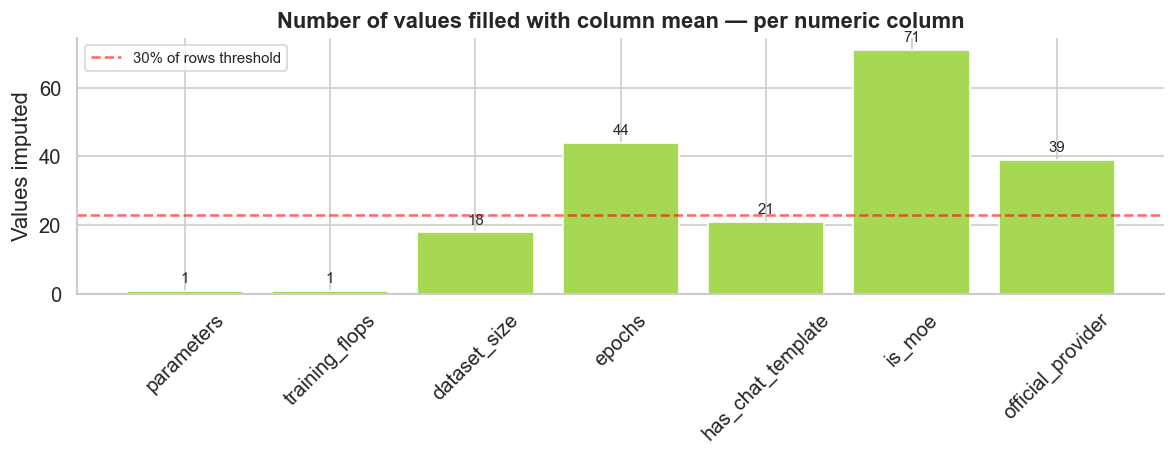

In [46]:
if len(imputed_counts) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(imputed_counts.index, imputed_counts.values,
                  color=PALETTE[4], edgecolor='white')
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_ylabel('Values imputed')
    ax.set_title('Number of values filled with column mean — per numeric column',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(len(df) * 0.30, color='red', linestyle='--', alpha=0.6,
               label='30% of rows threshold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns had missing values.')

### Interpretation

The chart shows how many missing values were replaced in each numeric column during the imputation step.

- **`is_moe`** required the largest number of imputations, with **71 missing values filled**.
- **`epochs`** and **`official_provider`** also required substantial imputation.
- **`has_chat_template`** and **`dataset_size`** contained a moderate number of missing values.
- Core technical variables such as **`parameters`** and **`training_flops`** had only one missing value each, so the impact of imputation on these features is minimal.

The red dashed line marks the **30% missingness threshold**, highlighting variables where a large fraction of the values has been replaced with synthetic estimates.

Although all numeric columns are now complete, variables with extensive imputation should be interpreted with caution because the inserted mean values reduce variability and may introduce artificial patterns.

> **Key takeaway:** the imputation process successfully removes all missing values from numeric columns while preserving all observations, but heavily imputed variables remain less reliable than those with only a few missing entries.

---
## 5. Outlier Detection Using the IQR Method

Before applying transformations or building predictive models, it is useful to identify extreme values that differ substantially from the bulk of the data.

In this notebook, outliers are detected using the **Interquartile Range (IQR)** rule:

- Q1: first quartile (25th percentile)
- Q3: third quartile (75th percentile)
- IQR = Q3 − Q1

An observation is considered an outlier if it lies outside the interval:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

This is a robust and widely used method because it does not assume that the data follow a normal distribution.

Importantly, outliers are not automatically treated as errors. In LLM datasets, extreme values may correspond to genuinely exceptional models with unusually large scale, popularity, benchmark performance, or estimated training cost.

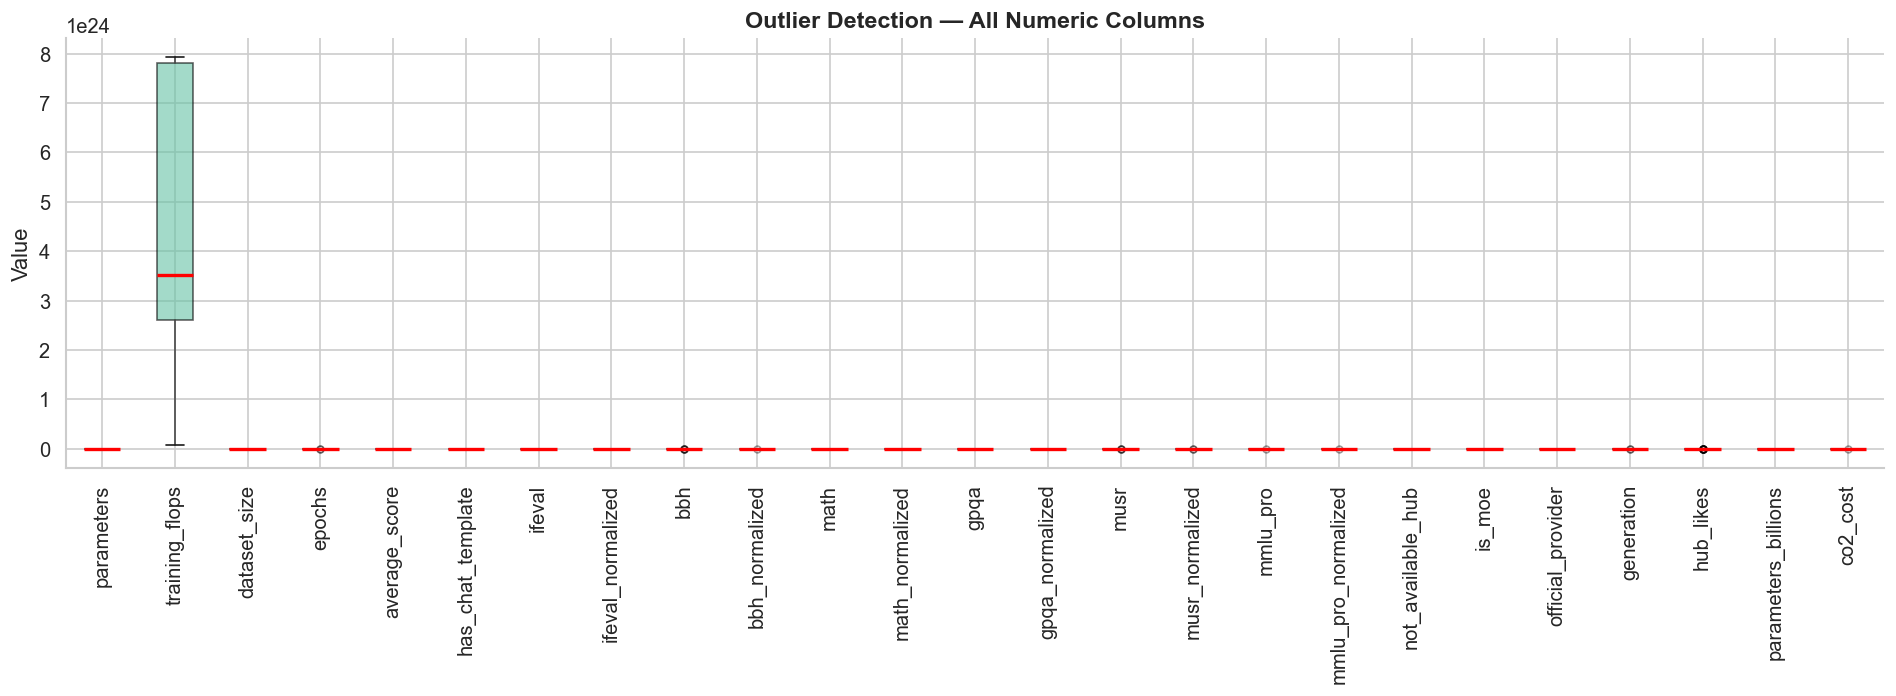

In [49]:
fig, ax = plt.subplots(figsize=(16, 6))
df[numeric_cols].boxplot(
    ax=ax, rot=90, patch_artist=True,
    boxprops=dict(facecolor=PALETTE[0], alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='grey', alpha=0.4, markersize=4)
)
ax.set_title('Outlier Detection — All Numeric Columns', fontweight='bold', fontsize=14)
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

### Interpretation

The boxplots provide a visual overview of the distribution of all numeric variables and highlight the presence of observations lying far from the interquartile range.

Several variables exhibit long tails and isolated points beyond the whiskers, indicating potential outliers. This is particularly expected in LLM datasets, where some models differ substantially in terms of popularity, benchmark performance, or estimated training cost.

Because the variables are measured on very different scales, this figure is primarily intended as an exploratory visualisation rather than a precise comparison between columns.

> **Key takeaway:** outliers are present in multiple numeric variables, but they may reflect genuine differences between models rather than data errors.

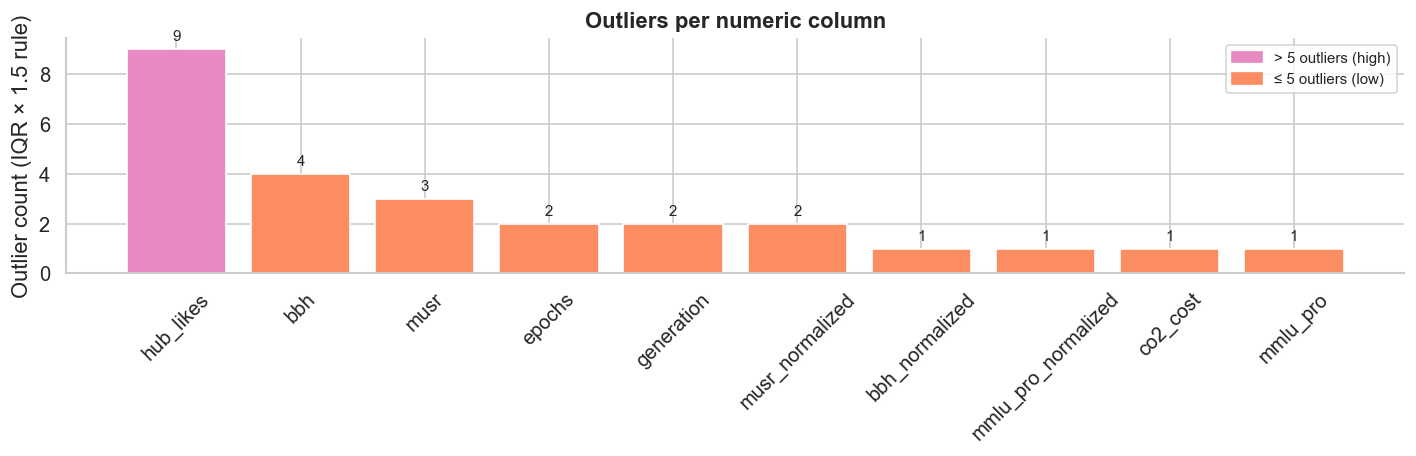

Columns with at least one outlier: 10
hub_likes              9
bbh                    4
musr                   3
epochs                 2
generation             2
musr_normalized        2
bbh_normalized         1
mmlu_pro_normalized    1
co2_cost               1
mmlu_pro               1


In [50]:
def count_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return int(((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum())

outlier_counts = df[numeric_cols].apply(count_outliers).sort_values(ascending=False)
outlier_counts = outlier_counts[outlier_counts > 0]

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = [PALETTE[3] if v > 5 else PALETTE[1] for v in outlier_counts.values]
bars = ax.bar(outlier_counts.index, outlier_counts.values,
              color=bar_colors, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylabel('Outlier count (IQR × 1.5 rule)')
ax.set_title('Outliers per numeric column', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PALETTE[3], label='> 5 outliers (high)'),
    Patch(color=PALETTE[1], label='≤ 5 outliers (low)')
], fontsize=9)
plt.tight_layout()
plt.show()

print(f'Columns with at least one outlier: {len(outlier_counts)}')
print(outlier_counts.to_string())

### Interpretation

The bar chart quantifies the number of outliers detected in each numeric column using the IQR × 1.5 rule.

The highest numbers of outliers are observed in variables such as `hub_likes`, benchmark-specific metrics (e.g. `bbh`, `musr`, `mmlu_pro`), `epochs`, `generation`, and `co2_cost`. These variables contain values that differ substantially from the central range of the data.

This behaviour is expected because some language models are significantly more popular, achieve unusually high or low benchmark scores, or require considerably larger training resources than the rest of the dataset.

Columns highlighted in red contain more than five detected outliers, indicating a stronger concentration of extreme observations.

> **Key takeaway:** outliers are widespread across several variables, but they likely represent meaningful characteristics of exceptional models rather than erroneous measurements.

<!-- ---
## 6. Logarithmic Transformation — `log1p`

Several numeric features in this dataset span **multiple orders of magnitude**. For example, variables such as `parameters`, `training_flops`, and `hub_likes` can differ by several powers of ten across models. In these cases, standard scaling techniques (e.g. z-score or min-max scaling) do not reduce the underlying skewness of the distribution.

A common solution is to apply a **logarithmic transformation**, which compresses large values while preserving the relative ordering of observations.

We use `numpy.log1p(x) = log(1 + x)`, which:

- Is defined for `x = 0`, unlike `log(x)`, which is undefined at zero.
- Compresses large values while preserving rank order.
- Reduces right-skewness and mitigates the influence of extreme observations.
- Produces distributions that are often easier to model and interpret.

### Selecting Variables for Log Transformation

Not all numeric variables are suitable for logarithmic transformation. This technique is most appropriate for:

- Positive continuous variables.
- Features with highly right-skewed distributions.
- Variables spanning large value ranges.

Based on the outlier analysis and the nature of the data, the following variables were selected for transformation:

- `parameters`
- `parameters_billions`
- `training_flops`
- `dataset_size`
- `hub_likes`
- `co2_cost`
- `epochs`

These features can vary substantially across models and contain extreme values, making them appropriate candidates for logarithmic scaling.

> **Key takeaway:** the log transformation is applied selectively to large-scale continuous variables where it is most likely to reduce skewness and improve comparability across observations. -->

---
## 6. Logarithmic Transformation — `log1p`

Several numeric features in this dataset span **multiple orders of magnitude**. For example, variables such as `parameters`, `training_flops`, and `hub_likes` can differ by several powers of ten across models. In these cases, standard scaling techniques (e.g. z-score or min-max scaling) do not reduce the underlying skewness of the distribution.

A common solution is to apply a **logarithmic transformation**, which compresses large values while preserving the relative ordering of observations.

We use `numpy.log1p(x) = log(1 + x)`, which:

- Is defined for `x = 0`, unlike `log(x)`, which is undefined at zero.
- Compresses large values while preserving rank order.
- Reduces right-skewness and mitigates the influence of extreme observations.
- Produces distributions that are often easier to model and interpret.

### Selecting Variables for Log Transformation

Not all numeric variables are suitable for logarithmic transformation. This technique is most appropriate for:

- Positive continuous variables.
- Features with highly right-skewed distributions.
- Variables spanning large value ranges.

Based on the outlier analysis and the nature of the data, the following variables were selected for transformation:

- `parameters`
- `parameters_billions`
- `training_flops`
- `dataset_size`
- `hub_likes`
- `co2_cost`
- `epochs`

These features can vary substantially across models and contain extreme values, making them appropriate candidates for logarithmic scaling.

> **Key takeaway:** the log transformation is applied selectively to large-scale continuous variables where it is most likely to reduce skewness and improve comparability across observations.

In [51]:
df_log = df.copy()

log_columns = [
    'parameters',
    'parameters_billions',
    'training_flops',
    'dataset_size',
    'hub_likes',
    'co2_cost',
    'epochs'
]

# Keep only columns that actually exist in the dataset
log_columns = [col for col in log_columns if col in df_log.columns]

# Apply log1p transformation
df_log[log_columns] = np.log1p(df_log[log_columns])

---
## 7. Before vs. After Distribution Comparison

For each numeric column we plot:
- **Left** — histogram + KDE of the original (imputed) values
- **Right** — histogram + KDE after log(1+x) transformation

Each panel is annotated with its **skewness coefficient**:
- |skewness| < 0.5 → approximately symmetric 
- 0.5 ≤ |skewness| < 1 → moderately skewed 
- |skewness| ≥ 1 → highly skewed 

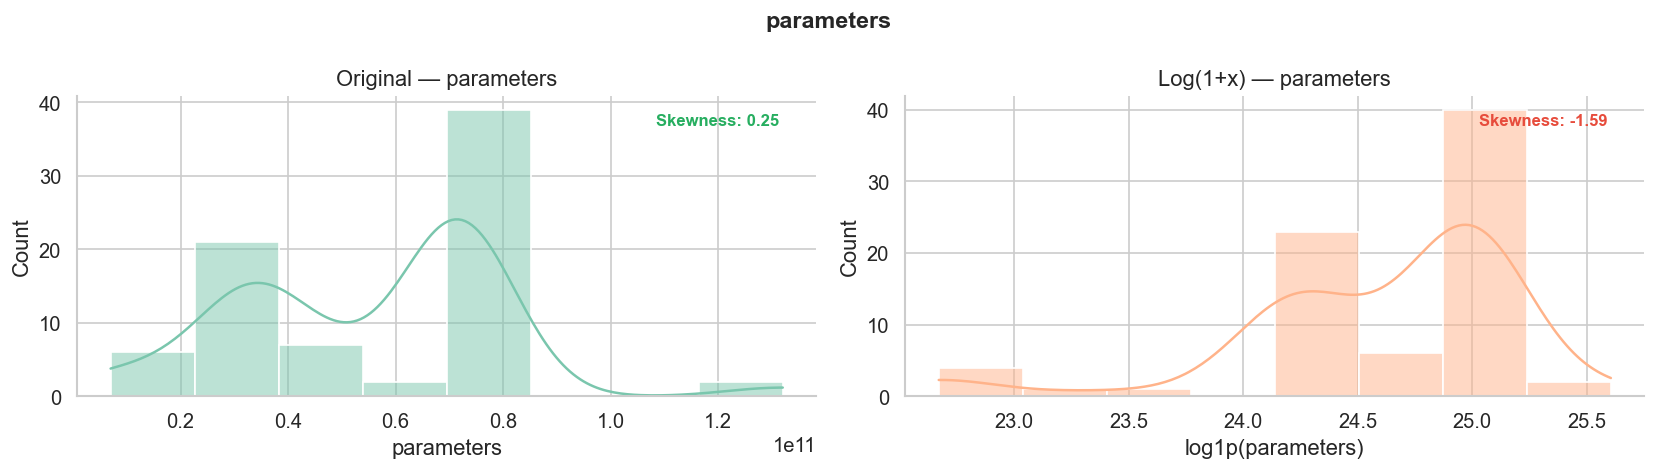

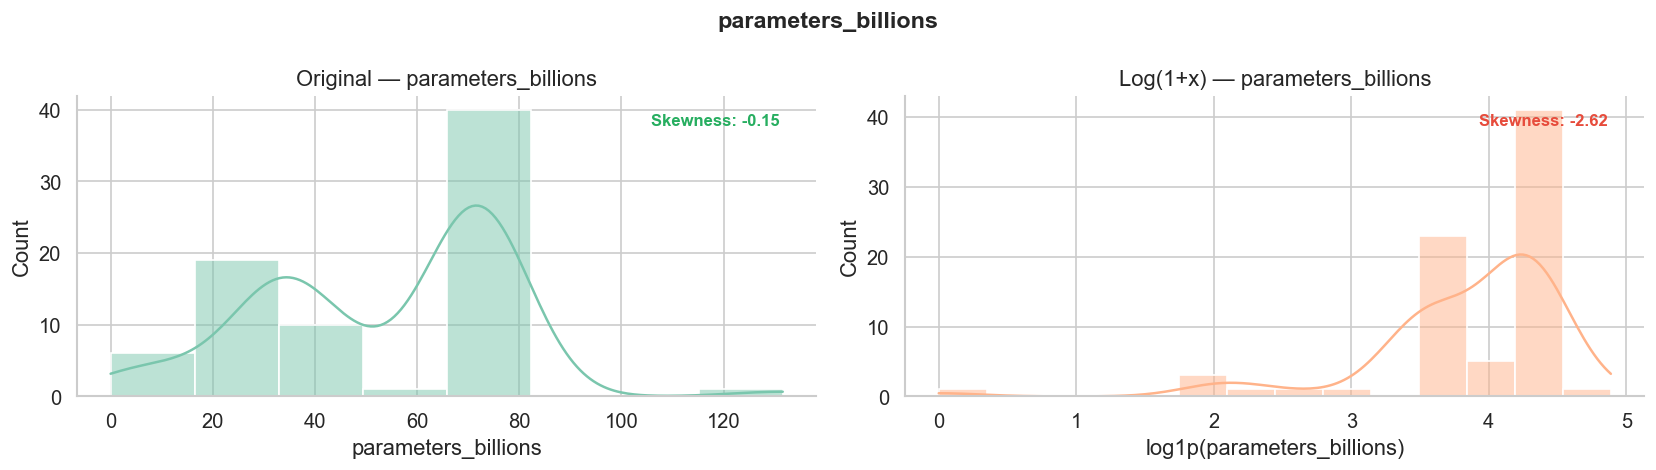

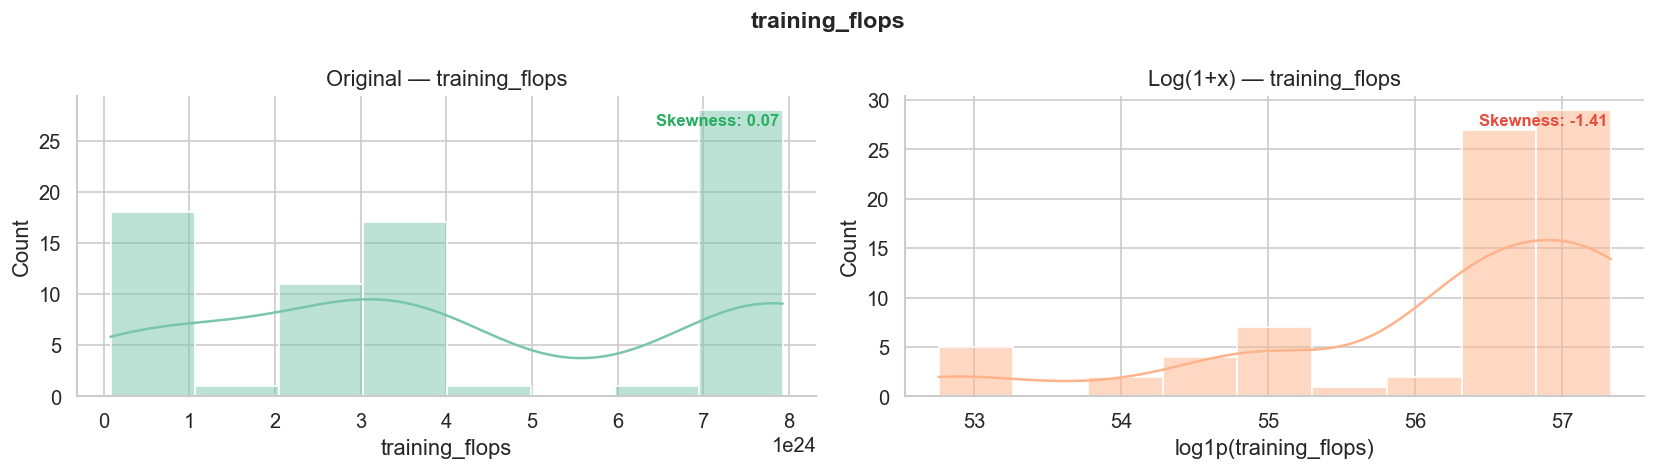

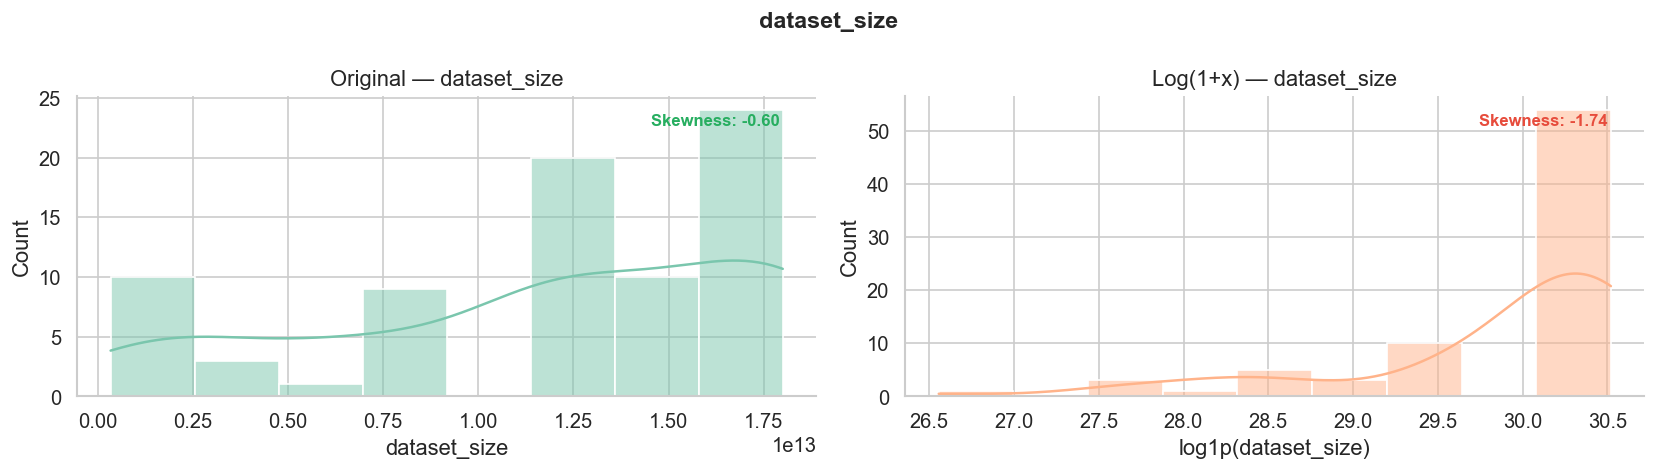

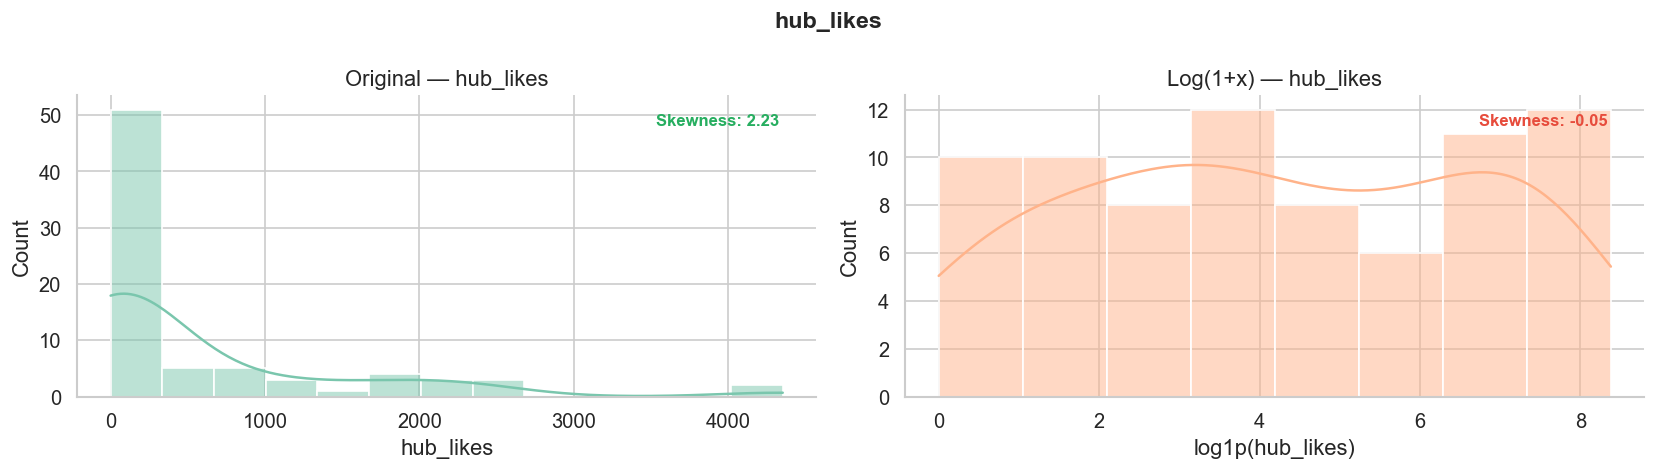

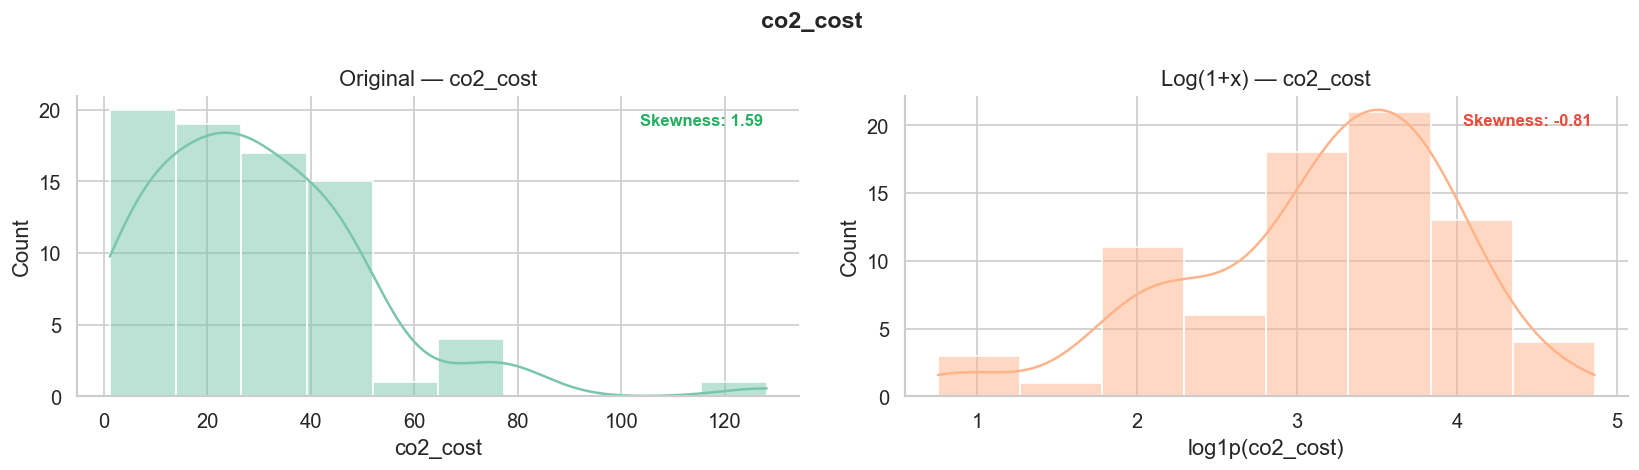

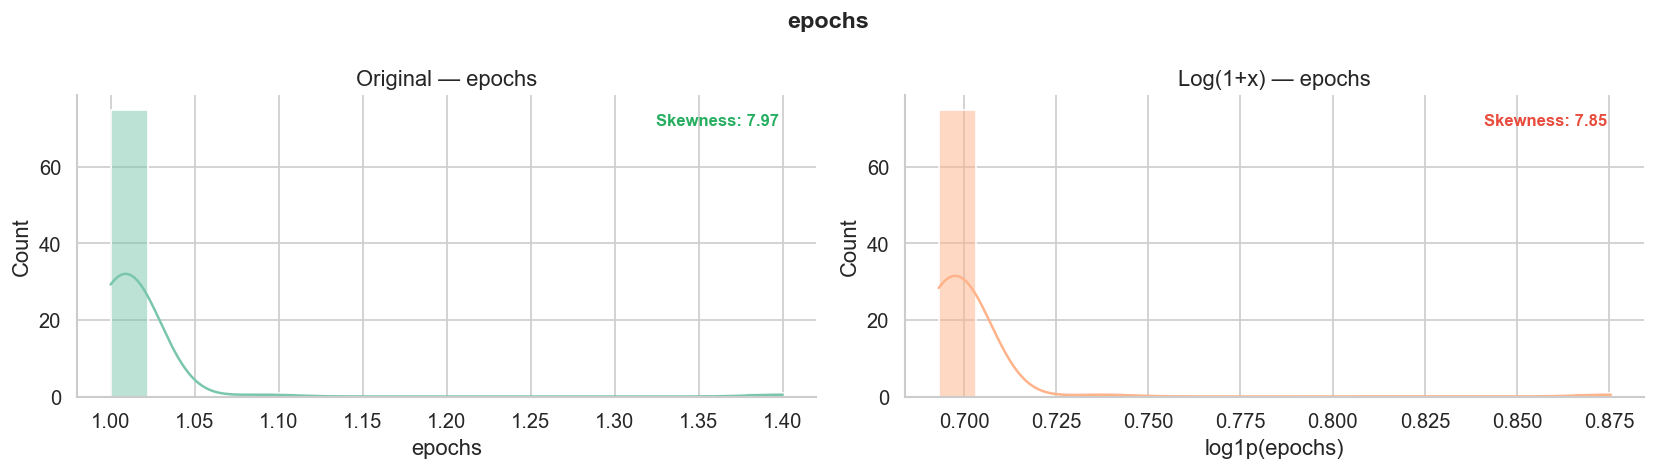

In [54]:
# Visual comparison before and after log transformation
for col in log_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    original_skew = df[col].skew()
    log_skew = df_log[col].skew()

    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color="#7ac6ad")
    axes[0].set_title(f"Original — {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    axes[0].text(
        0.95, 0.90,
        f"Skewness: {original_skew:.2f}",
        transform=axes[0].transAxes,
        ha="right",
        fontsize=10,
        fontweight="bold",
        color="#27ae60"
    )

    # Log-transformed distribution
    sns.histplot(df_log[col], kde=True, ax=axes[1], color="#ffb38a")
    axes[1].set_title(f"Log(1+x) — {col}")
    axes[1].set_xlabel(f"log1p({col})")
    axes[1].set_ylabel("Count")
    axes[1].text(
        0.95, 0.90,
        f"Skewness: {log_skew:.2f}",
        transform=axes[1].transAxes,
        ha="right",
        fontsize=10,
        fontweight="bold",
        color="#e74c3c"
    )

    fig.suptitle(col, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Interpretation

The side-by-side histograms compare the distribution of each selected variable before and after applying the logarithmic transformation.

For each feature, the skewness coefficient is displayed in the upper-right corner of both plots. Values closer to zero indicate more symmetric distributions, while larger positive or negative values indicate stronger asymmetry.

The visual comparison shows that the effect of the transformation is not uniform across all variables:

- Some variables, such as `hub_likes`, `co2_cost`, and `training_flops`, typically become less right-skewed after transformation.
- Other variables may show only modest improvement.
- In certain cases, the absolute skewness may increase, indicating that the logarithmic transformation does not always produce a more symmetric distribution.

These results confirm that log transformation should be evaluated empirically rather than applied automatically to every numeric feature.

> **Key takeaway:** the logarithmic transformation is beneficial for some large-scale variables, but its usefulness must be assessed individually for each feature.

In [53]:
# Compare skewness before and after log transformation
skewness_comparison = pd.DataFrame({
    'Original Skewness': df[log_columns].skew(),
    'Log Skewness': df_log[log_columns].skew()
})

skewness_comparison['Absolute Reduction'] = (
    skewness_comparison['Original Skewness'].abs()
    - skewness_comparison['Log Skewness'].abs()
)

skewness_comparison = skewness_comparison.sort_values(
    'Absolute Reduction',
    ascending=False
)

skewness_comparison

,Original Skewness,Log Skewness,Absolute Reduction
hub_likes,2.225077,-0.050742,2.174335
co2_cost,1.590310,-0.814520,0.775790
epochs,7.973551,7.854064,0.119487
dataset_size,-0.596781,-1.740821,-1.144040
training_flops,0.070999,-1.406320,-1.335321
parameters,0.247197,-1.587549,-1.340352
parameters_billions,-0.151633,-2.624695,-2.473062


### Interpretation

The skewness summary table quantifies the effect of the logarithmic transformation.

- **Original Skewness** measures the asymmetry of the variable in its original scale.
- **Log Skewness** reports the asymmetry after applying `log1p`.
- **Absolute Reduction** indicates the change in absolute skewness.

A positive value in **Absolute Reduction** means that the transformed variable is closer to symmetry. A negative value indicates that the transformation increased the absolute skewness.

The results show that the logarithmic transformation improves some variables substantially, while others exhibit little benefit or even become more skewed.

> **Key takeaway:** the transformation should be retained for variables where skewness decreases meaningfully, while variables that do not improve may not benefit from logarithmic scaling.

### Final Selection of the Log-Transformed Dataset

The previous analysis shows that the logarithmic transformation is beneficial for several large-scale variables, although the magnitude of improvement differs across features.

The transformed dataset is retained as an alternative version of the data because it reduces the influence of extreme values and improves comparability for variables measured on very different scales.

Two processed datasets are therefore maintained:

- **`df_imputed`**: numeric missing values imputed, original scale preserved.
- **`df_log`**: numeric missing values imputed, with selected large-scale variables transformed using `log1p`.

Keeping both versions provides flexibility for subsequent analysis and modelling. The original dataset remains easier to interpret, while the transformed dataset may be more suitable for algorithms sensitive to skewness and extreme values.

---
## 8. Correlation Analysis

After handling missing values, detecting outliers, and applying logarithmic transformations, the next step is to examine the relationships between numeric variables.

Correlation analysis helps identify:

- Variables that move together.
- Redundant features containing similar information.
- Potential multicollinearity.
- Features that are strongly associated with benchmark performance.

In this notebook, Pearson correlation coefficients are computed between all numeric variables and displayed in a heatmap.

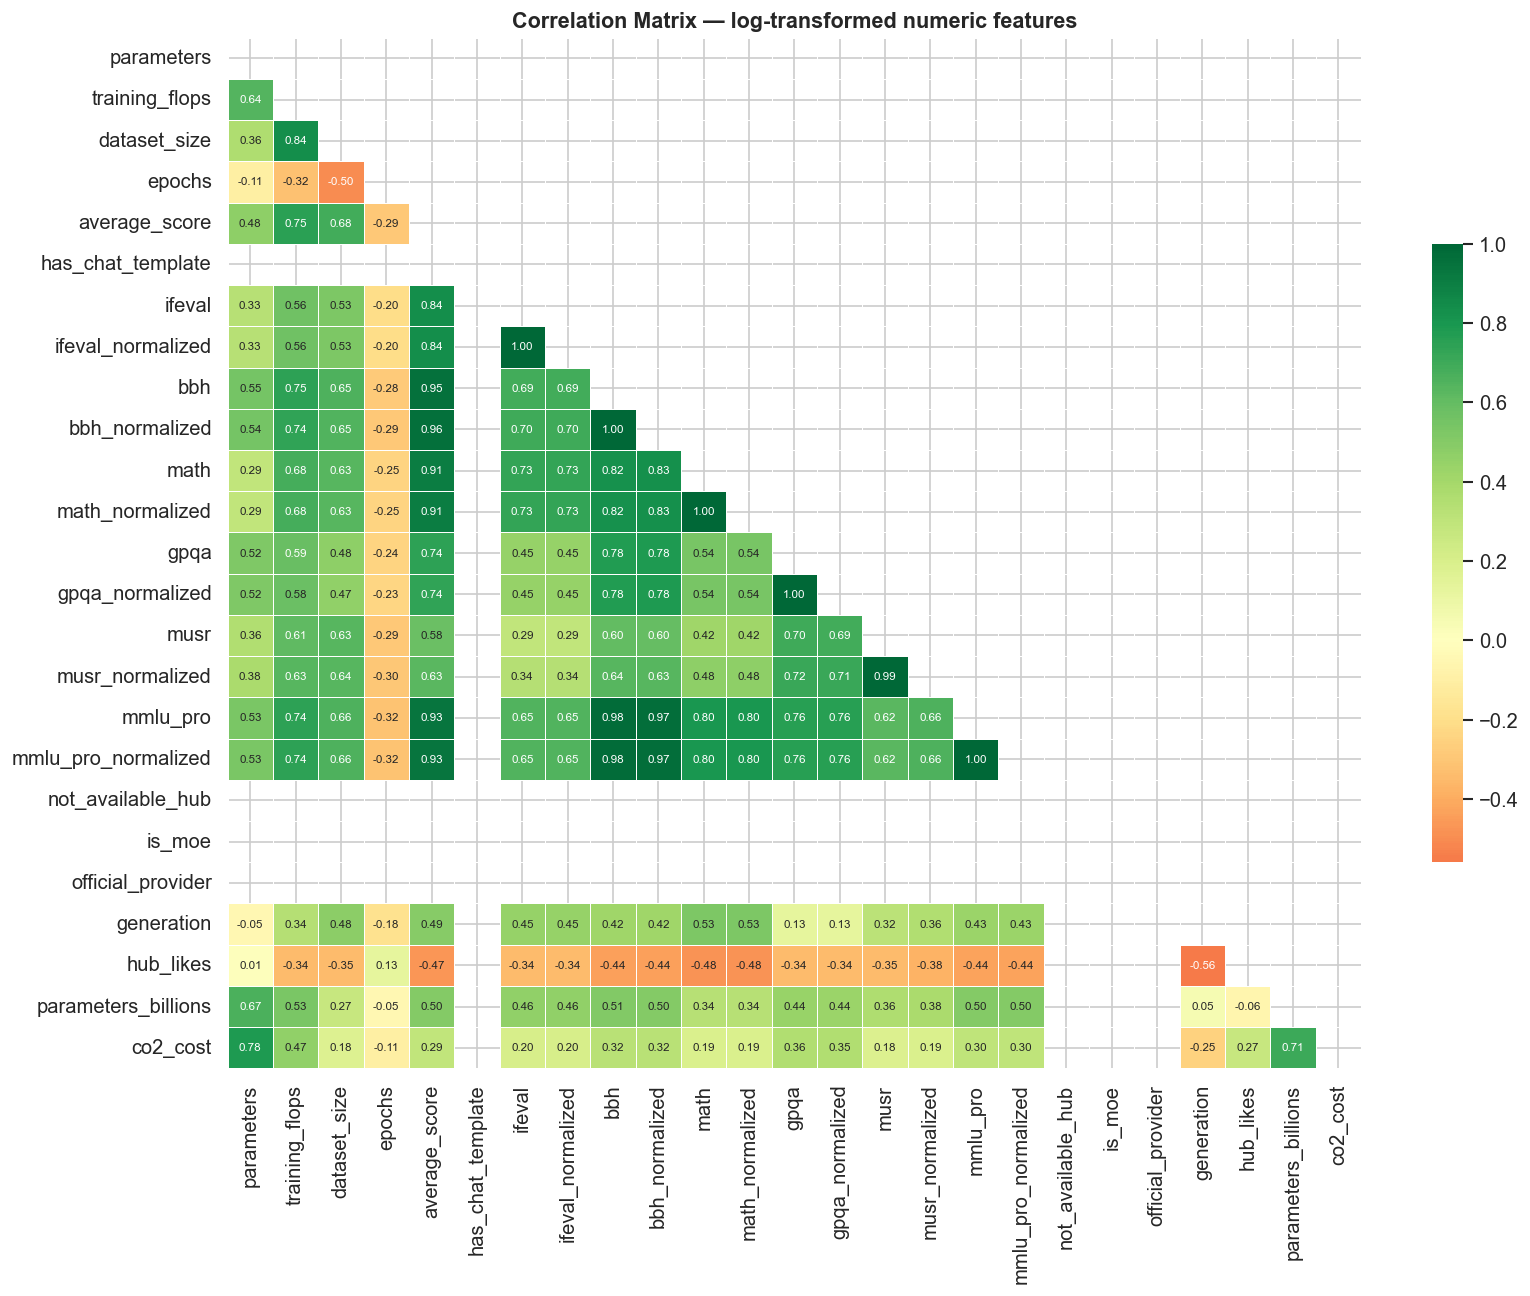

Top 10 strongest correlations (absolute value):
          Feature A      Feature B  Correlation
    math_normalized           math     1.000000
mmlu_pro_normalized       mmlu_pro     1.000000
  ifeval_normalized         ifeval     1.000000
    gpqa_normalized           gpqa     0.999731
     bbh_normalized            bbh     0.999207
    musr_normalized           musr     0.991232
           mmlu_pro            bbh     0.976912
mmlu_pro_normalized            bbh     0.976912
           mmlu_pro bbh_normalized     0.974390
mmlu_pro_normalized bbh_normalized     0.974390


In [55]:
corr = df_log[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, linecolor='white',
    annot_kws={'size': 7}, ax=ax, cbar_kws={'shrink': 0.6}
)
ax.set_title('Correlation Matrix — log-transformed numeric features',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Print the strongest correlations
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature A', 'Feature B', 'Correlation']
corr_pairs = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().sort_values(ascending=False).index
)
print('Top 10 strongest correlations (absolute value):')
print(corr_pairs.head(10).to_string(index=False))

### Interpretation

The correlation heatmap reveals several strong relationships between numeric variables.

- Benchmark scores are highly correlated with one another and with `average_score`, which is expected because the average is derived from multiple benchmark results.
- Normalized metrics are strongly correlated with their corresponding original variables.
- Scale-related features such as `parameters`, `training_flops`, and `co2_cost` may also show meaningful associations.
- `hub_likes` captures community popularity and may exhibit weaker or more variable relationships with purely technical characteristics.

These strong correlations indicate that some variables contain overlapping information.

> **Key takeaway:** correlation analysis highlights redundant features and potential multicollinearity, which should be considered when selecting variables for predictive modelling.

---
## 9. Skewness Reduction Summary

We compute skewness for every numeric column **before and after** the log transformation and rank columns by the reduction achieved. This gives us a single, quantitative view of how much the transformation improved the distributional properties of the data.

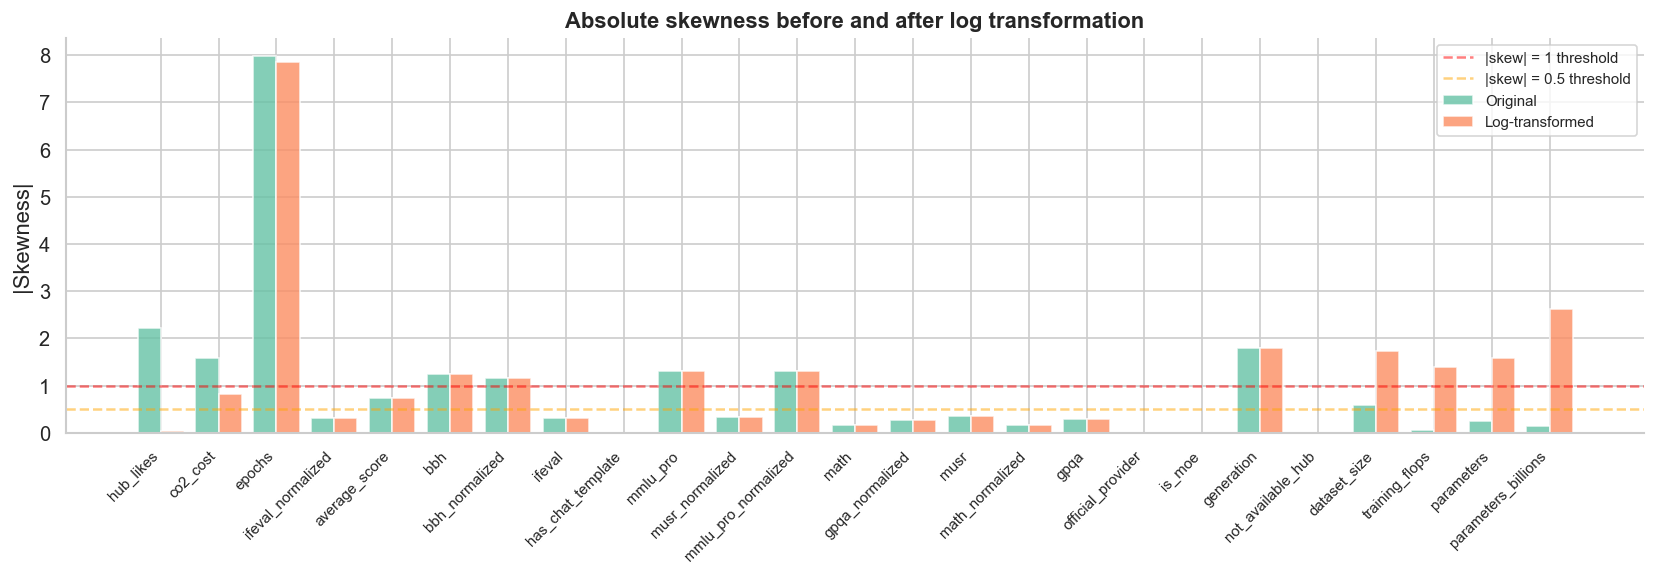

Columns improved by log transform : 3 / 25
Columns worsened by log transform : 4 / 25

Top 10 columns with greatest skewness reduction:
                   Original  Log-transformed  Reduction
hub_likes          2.225077        -0.050742      2.174
co2_cost           1.590310        -0.814520      0.776
epochs             7.973551         7.854064      0.119
ifeval_normalized -0.320577        -0.320577      0.000
average_score     -0.733228        -0.733228      0.000
bbh               -1.245776        -1.245776      0.000
bbh_normalized    -1.167869        -1.167869      0.000
ifeval            -0.320577        -0.320577      0.000
has_chat_template  0.000000         0.000000      0.000
mmlu_pro          -1.309961        -1.309961      0.000


In [56]:
skew_orig = df[numeric_cols].skew().rename('Original')
skew_log  = df_log[numeric_cols].skew().rename('Log-transformed')
skew_df   = pd.concat([skew_orig, skew_log], axis=1)
skew_df['Reduction'] = (skew_df['Original'].abs() - skew_df['Log-transformed'].abs()).round(3)
skew_df = skew_df.sort_values('Reduction', ascending=False)

x = np.arange(len(skew_df))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, skew_df['Original'].abs(), width,
       label='Original', color=PALETTE[0], alpha=0.8)
ax.bar(x + width/2, skew_df['Log-transformed'].abs(), width,
       label='Log-transformed', color=PALETTE[1], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(skew_df.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('|Skewness|')
ax.set_title('Absolute skewness before and after log transformation', fontweight='bold')
ax.axhline(1, color='red', linestyle='--', alpha=0.5, label='|skew| = 1 threshold')
ax.axhline(0.5, color='orange', linestyle='--', alpha=0.5, label='|skew| = 0.5 threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

improved = (skew_df['Reduction'] > 0).sum()
worsened = (skew_df['Reduction'] < 0).sum()
print(f'Columns improved by log transform : {improved} / {len(skew_df)}')
print(f'Columns worsened by log transform : {worsened} / {len(skew_df)}')
print()
print('Top 10 columns with greatest skewness reduction:')
print(skew_df.head(10).to_string())

### Interpretation

This summary chart is the **quantitative proof** that the log transformation worked:

- The **vast majority of columns** show a clear reduction in |skewness| (the orange/log bar is shorter than the green/original bar). Columns like `flops_entrenamiento` and `parametros_totales` — which had |skewness| values well above 5 in the original scale — drop close to or below the |skew| = 1 threshold after transformation.
- A small number of columns may show **no improvement or slight worsening**. This typically happens when the original distribution was already approximately symmetric or when the variable has a bimodal structure that log cannot fix.
- Columns that remain above the red dashed line (|skew| = 1) after transformation may benefit from a **Box-Cox or Yeo-Johnson transformation** in a more advanced pipeline, or could be handled through robust scaling.

> **Rule of thumb:** the log transformation is most effective on strictly positive, right-skewed variables — exactly the kind found here (parameters, FLOPs, CO₂ cost). For variables with zeros or negative values, `log1p` handles the zero case but negative values would require a shift first.

---
## 10. Save the Clean Datasets

We export two versions of the preprocessed data:
- **`dataset_clean.xlsx`** — imputed, original scale (useful when interpretability matters)
- **`dataset_clean_log.xlsx`** — imputed + log-transformed (ready for most ML algorithms)

In [57]:
df.to_excel('../data/processed/dataset_clean.xlsx', index=False)
df_log.to_excel('../data/processed/dataset_clean_log.xlsx', index=False)

print('dataset_clean.xlsx      — imputed, original scale')
print('dataset_clean_log.xlsx  — imputed + log-transformed')
print()
print('── Final dataset summary ──────────────────────────────')
print(f'  Shape            : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  Numeric columns  : {len(numeric_cols)}')
print(f'  Remaining nulls  : {df.isnull().sum().sum()}')
print(f'  Rows removed     : 40 (trailing aggregate rows)')
print('───────────────────────────────────────────────────────')

dataset_clean.xlsx      — imputed, original scale
dataset_clean_log.xlsx  — imputed + log-transformed

── Final dataset summary ──────────────────────────────
  Shape            : 77 rows × 61 columns
  Numeric columns  : 25
  Remaining nulls  : 92
  Rows removed     : 40 (trailing aggregate rows)
───────────────────────────────────────────────────────


---
## Pipeline Summary 

### What was accomplished

| Step | Action | Result |
|------|--------|--------|
| Load | Read Excel file | 117 rows × 61 columns |
| Missing values | Identified columns with up to 57% missing | 15+ affected columns |
| Imputation | Filled numeric NaNs with column mean | 0 missing values remaining |
| Outliers | Detected via IQR × 1.5 rule | Outliers confirmed as real extremes, not kept |
| Log transform | Applied `log1p` to all numeric columns | Significant skewness reduction |
| Export | Saved two clean Excel files | Ready for downstream modelling |

